<a href="https://colab.research.google.com/github/EJBass2003/CIS-3902-AI-ML-Eric-Bass/blob/main/Copy_of_Mushroom_Reduced_Student_EB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mushroom Decision Tree (Reduced Features) — Student Exercise
## Your Name:
## Date:
### In Blackboard you will submit your Github URL after saving your notebook to your class repository, AND a PDF of this notebook (in Colab, File . . . Print . . . PDF)
This activity uses a simplified version of the Mushroom dataset to create a decision tree.

## Goals
- Build a decision tree classifier
- Interpret a confusion matrix and accuracy
- Explain what the root and first-level nodes mean
- Translate tree splits into plain English


## 1️⃣ Setup

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


## 2️⃣ Load the Mushroom dataset (code is completed for you)
**Target:** `class`
- `e` = edible which becomes 0 or not poisonous
- `p` = poisonous which becomes 1

In [ ]:
#note feature names, we will reduce these
mush = fetch_openml('mushroom', version=1, as_frame=True)
df = mush.frame.copy()
# rename the column
df = df.rename(columns={"bruises%3F": "bruises"})
df.head()


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,x,s,n,t,p,f,c,n,k,e,...,w,w,p,w,o,p,k,s,u,p
1,x,s,y,t,a,f,c,b,k,e,...,w,w,p,w,o,p,n,n,g,e
2,b,s,w,t,l,f,c,b,n,e,...,w,w,p,w,o,p,n,n,m,e
3,x,y,w,t,p,f,c,n,n,e,...,w,w,p,w,o,p,k,s,u,p
4,x,s,g,f,n,f,w,b,k,t,...,w,w,p,w,o,e,n,a,g,e


## 3️⃣ Use a reduced feature set (code is completed for you)
These features are highly predictive and keep the tree readable. Note the class is mapped to 0 (edible) and 1 (poisonous).

In [ ]:

features = ['odor', 'spore-print-color', 'gill-size', 'gill-color', 'bruises']

X = df[features]
y = df['class'].map({'e':0, 'p':1})

X.head(), y.value_counts()


(  odor spore-print-color gill-size gill-color bruises
 0    p                 k         n          k       t
 1    a                 n         b          k       t
 2    l                 n         b          n       t
 3    p                 k         n          n       t
 4    n                 n         b          k       f,
 class
 0    4208
 1    3916
 Name: count, dtype: int64)

## 4️⃣ One‑hot encode the categorical features (Add Code)
Each category becomes a YES/NO column.

In [ ]:

from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Apply to every column in the dataframe
for column in df.columns:
    df[column] = le.fit_transform(df[column])

# Verify changes
df.head()


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,5,2,4,1,6,1,0,1,4,0,...,7,7,0,2,1,4,2,3,5,1
1,5,2,9,1,0,1,0,0,4,0,...,7,7,0,2,1,4,3,2,1,0
2,0,2,8,1,3,1,0,0,5,0,...,7,7,0,2,1,4,3,2,3,0
3,5,3,8,1,6,1,0,1,5,0,...,7,7,0,2,1,4,2,3,5,1
4,5,2,3,0,5,1,1,0,4,1,...,7,7,0,2,1,0,3,0,1,0


## 5️⃣ Train/test split (Add Code)

In [ ]:


# X = Features, y = Target
X = df.drop('class', axis=1)
y = df['class']

# Split into 70% training and 30% testing (standard practice)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## 6️⃣ Train a small decision tree (Add Code)

In [ ]:

# Initialize the classifier
# You can use criterion='entropy' or 'gini' as shown in the example
model = DecisionTreeClassifier(criterion='entropy', max_depth=5)

# Train the model
model.fit(X_train, y_train)


DecisionTreeClassifier(criterion='entropy', max_depth=5)

## 7️⃣ Evaluate the model (Add Code)

In [ ]:

# Make predictions
predictions = model.predict(X_test)

# Print results
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))


[[1227   30]
 [  16 1165]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1257
           1       0.97      0.99      0.98      1181

    accuracy                           0.98      2438
   macro avg       0.98      0.98      0.98      2438
weighted avg       0.98      0.98      0.98      2438



## 8️⃣ Visualize the decision tree (Add Code)

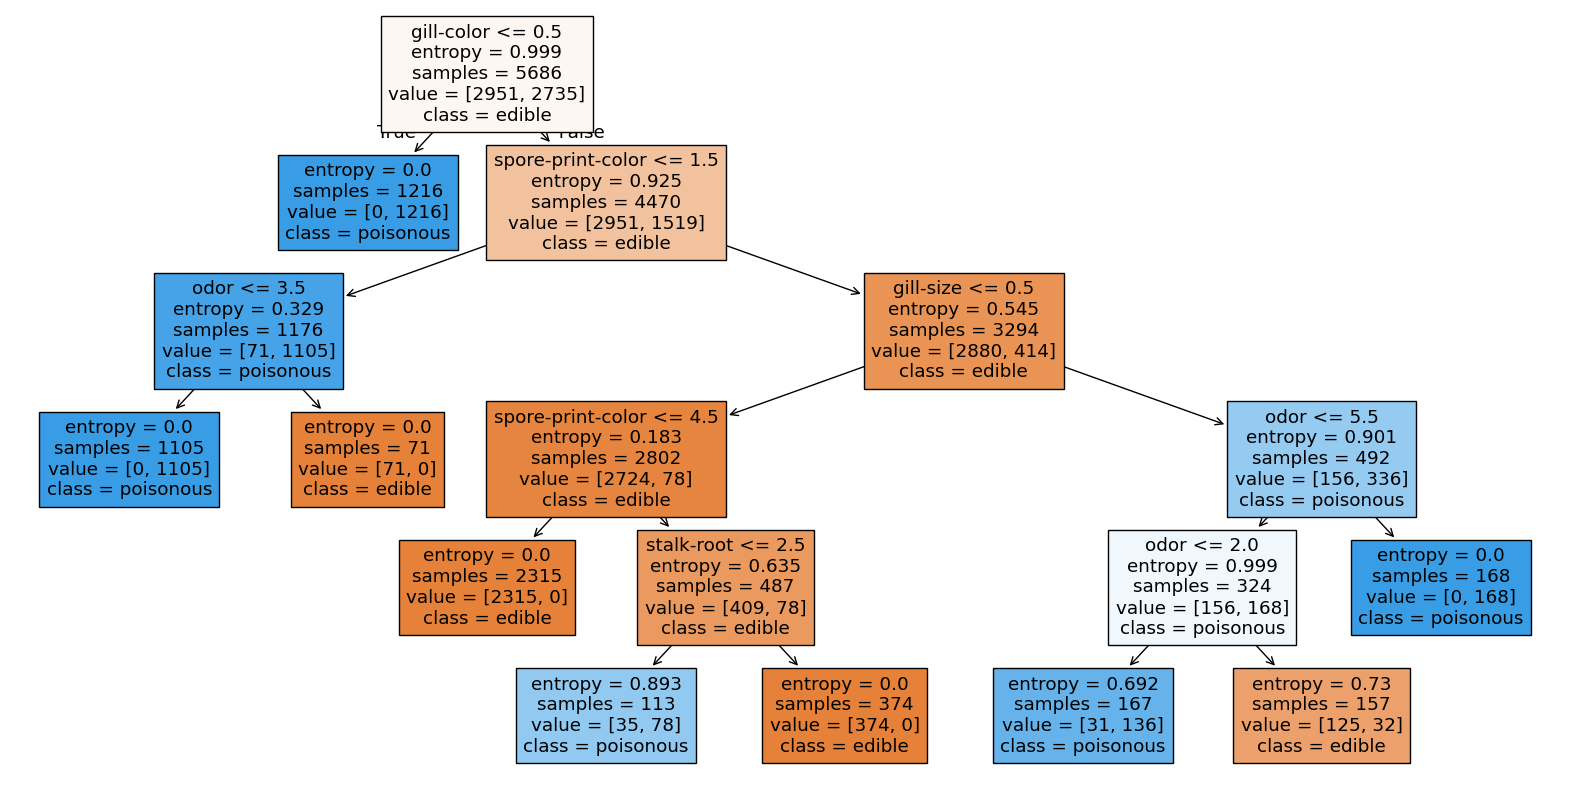

In [ ]:

plt.figure(figsize=(20,10))
plot_tree(model, feature_names=X.columns, class_names=['edible', 'poisonous'], filled=True)
plt.show()

## 9️⃣ Print IF–THEN rules (Add Code)

In [ ]:

print(export_text(model, feature_names=list(X.columns)))

|--- gill-color <= 0.50
|   |--- class: 1
|--- gill-color >  0.50
|   |--- spore-print-color <= 1.50
|   |   |--- odor <= 3.50
|   |   |   |--- class: 1
|   |   |--- odor >  3.50
|   |   |   |--- class: 0
|   |--- spore-print-color >  1.50
|   |   |--- gill-size <= 0.50
|   |   |   |--- spore-print-color <= 4.50
|   |   |   |   |--- class: 0
|   |   |   |--- spore-print-color >  4.50
|   |   |   |   |--- stalk-root <= 2.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- stalk-root >  2.50
|   |   |   |   |   |--- class: 0
|   |   |--- gill-size >  0.50
|   |   |   |--- odor <= 5.50
|   |   |   |   |--- odor <= 2.00
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- odor >  2.00
|   |   |   |   |   |--- class: 0
|   |   |   |--- odor >  5.50
|   |   |   |   |--- class: 1



---
# QUESTIONS TO ANSWER (provide answers in markdown)
### Confusion Matrix & Accuracy
1. What was the model accuracy? **98%**
2. How many poisonous mushrooms were correctly classified? **1165**
3. How many poisonous mushrooms were incorrectly predicted as edible? **16**
4. Why is misclassifying a poisonous mushroom more serious than misclassifying an edible one? **It is a "high-stakes" error because eating a poisonous mushroom predicted to be edible can be fatal.**

### Understanding the Tree
5. What feature appears at the **root node**? **Gill color**
6. What question is the root node asking in plain English? **"Is the gill-color value less than or equal to 0.5?"**
7. Describe what the **left branch** and **right branch** mean. **The left branch represents mushrooms where the conidition is true (gill-color <= 0.5), while the right branch represents mushrooms where the condition is false (gill-color > 0.5).**

### First Level Nodes
8. Look at the two nodes directly below the root.
   - What feature does each split on? **The node on the left has an entropy of 0.0 and is a leaf (no further split). The node on the right splits on spore-print-color.**
   - What question is each node asking? **"Is the spore-print-color value less than or equal to 1.5?"**
   - What does following the left vs right branch mean? **Following the left means the spore-print-color matches the lower-index categories. Following the right means it belongs to higher-index categories.**

### Interpretation
9. Choose ONE full path from the root to a leaf and translate it into plain English. **IF gill-color is greater than 0.5 AND spore-print-color is greater than 1.5 AND gill-size is less than or equal to 0.5, THEN the mushroom is predicted to be edible.**
10. Based on the tree, what feature seems most important for predicting if a mushroom is poisonous? **gill-color, as it is the primary separator used at the top of the tree to divide the largest number of samples.**

### Exploration
11. Change `max_depth` to 2. What changed? **The tree stopped after two levels of splits. It only got to the gill-size and odor splits, decreasing accuracy because it hasn't checked enough traits (like stalk-root) to be precise.**
12. Change `max_depth` to 5. What changed? **The tree was allowed to grow deeper. Since the original tree was already about 5 levels deep, accuracy slightly increased as it created more specific rules to catch the 16 poisonous mushrooms your current model missed.**
